# Apo enzyme research analysis — GK13, ANC45, ANC55 and ANC56

Existing production data only: total energy and optimally aligned N/CA/C backbone RMSD, **0–200 ns**. Plot units: **ns**, **Å**, **kJ/mol**. Saved RMSD CSVs remain in **nm**; plotting converts nm × 10 to Å. Energy/RMSD calculations and plotting styles are adapted from [the enzyme–PHA notebook](enzyme_pha_analysis/enzyme_pha_analysis.ipynb); that notebook and teaching notebooks 01–12 are unchanged.

**To redraw figures:** leave `RUN_ANALYSIS=False` and Run All, or run **1. Paths**, **5. Plot settings**, then any individual plot cell. CSVs are reused without trajectory processing. To calculate new data, set `RUN_ANALYSIS=True`, choose a new `OUTPUT_TAG`, and Run All with the `ipha_clean` environment and GROMACS on PATH. Set it back to `False` afterwards.

GK13 and ANC45 comparisons reuse verified PHA RMSD CSVs. All curves measure displacement from **each simulation's own 0 ns backbone**, with the same atom selection and equal-weight translation/rotation fitting. The starting structures are not identical: these are not RMSDs to one common coordinate reference.

## 1. Paths and sampling

Verified in each `PHA_APO/<enzyme>_gromacs/` folder:
- `step7_production.edr`
- `step7_production.tpr`
- `analysis/processed_protein_centered.xtc` (full trajectory; not the `every100` preview)

`STRIDE=1` uses all 2,001 frames (0.1 ns spacing). No merging, preprocessing or simulations are performed. Data/log/summary files are protected by `OVERWRITE=False`. Plotting replaces PNGs only, or set `SAVE_FIGURES=False` below to preview.

In [1]:
from pathlib import Path
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

BASE_DIR = Path("/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs")
SYSTEMS = ["GK13", "ANC45", "ANC55", "ANC56"]
COMPARISON_SYSTEMS = ["GK13", "ANC45"]
STRIDE = 1
START_NS = 0.0
END_NS = 200.0
OUTPUT_TAG = "apo_research_0_200ns"
PHA_OUTPUT_TAG = "research_0_1000ns"
RUN_ANALYSIS = False
OVERWRITE = False
BACKBONE_SELECTION = "protein and name N CA C"
REFERENCE_POLICY = "each trajectory's own first frame at 0 ns"
ALIGNMENT = "equal-weight backbone RMSD; optimal translation and rotation"

if type(STRIDE) is not int or STRIDE < 1:
    raise ValueError("STRIDE must be a positive integer.")
if START_NS != 0 or END_NS != 200:
    raise ValueError("This notebook compares the shared 0–200 ns interval.")
for tag in (OUTPUT_TAG, PHA_OUTPUT_TAG):
    if not tag or any(c not in "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_-" for c in tag):
        raise ValueError("Output tags must contain only letters, numbers, underscores or hyphens.")

def apo_prefix(enzyme):
    return BASE_DIR / "PHA_APO" / f"{enzyme}_gromacs" / "analysis" / f"{enzyme}_{OUTPUT_TAG}"

def input_paths(enzyme):
    folder = BASE_DIR / "PHA_APO" / f"{enzyme}_gromacs"
    return {"edr": folder / "step7_production.edr", "tpr": folder / "step7_production.tpr",
            "xtc": folder / "analysis" / "processed_protein_centered.xtc"}


## 2. Calculation helpers and small checks

The protein must be a single whole molecule. Its bonds are checked in every analysed frame before fitting. RMSD uses coordinate copies and `superposition=True`, which removes translation and rotation; divide MDAnalysis Å values by 10 for nm. An independent NumPy SVD alignment checks the first, middle and last frames. Only one trajectory frame is held at a time; temporary symlinks keep XTC offset caches outside simulation folders.

`gmx energy` selects **Total-Energy by name**, retaining every EDR sample in 0–200 ns. Calculation dependencies and input checks run only when `RUN_ANALYSIS=True`.

In [2]:
if RUN_ANALYSIS:
    import shutil
    import subprocess
    from contextlib import contextmanager
    from tempfile import TemporaryDirectory
    import MDAnalysis as mda
    from MDAnalysis.analysis.rms import rmsd

    GMX = shutil.which("gmx") or shutil.which("gmx_mpi")
    if GMX is None:
        raise RuntimeError("Load GROMACS so gmx or gmx_mpi is on PATH.")

    reference_test = np.array([[0., 0., 0.], [1., 0., 0.], [0., 2., 0.], [0., 0., 3.]])
    rotation_test = np.array([[0., -1., 0.], [1., 0., 0.], [0., 0., 1.]])
    assert rmsd(reference_test @ rotation_test + [4., -3., 2.], reference_test,
                superposition=True) / 10 < 1e-7
    scaled_test = reference_test * 2
    expected_nm = np.sqrt(np.mean(np.sum((reference_test - reference_test.mean(axis=0))**2, axis=1))) / 10
    assert np.isclose(rmsd(scaled_test, reference_test, superposition=True) / 10, expected_nm)
    print("Rotation/translation removal and Å-to-nm conversion passed.")

    @contextmanager
    def open_trajectory(paths):
        with TemporaryDirectory(prefix="ipha_apo_") as scratch:
            linked_xtc = Path(scratch) / "trajectory.xtc"
            linked_xtc.symlink_to(paths["xtc"])
            u = mda.Universe(str(paths["tpr"]), str(linked_xtc))
            try:
                if u.atoms.n_atoms != u.trajectory.n_atoms:
                    raise ValueError("Topology/trajectory atom counts differ.")
                yield u
            finally:
                u.trajectory.close()


def fingerprints(paths):
    return {key: [p.stat().st_size, p.stat().st_mtime_ns] for key, p in paths.items()}


def backbone_identity(backbone):
    return [[int(a.resid), str(a.resname), str(a.name)] for a in backbone]


def check_protein(u):
    protein = u.select_atoms("protein")
    backbone = u.select_atoms(BACKBONE_SELECTION)
    if not len(protein) or len(protein.fragments) != 1:
        raise ValueError("Expected one connected protein molecule.")
    if len(backbone) != 3 * len(protein.residues):
        raise ValueError("Expected one N, CA and C atom per protein residue.")
    for residue in protein.residues:
        if sorted(residue.atoms.select_atoms("name N CA C").names) != ["C", "CA", "N"]:
            raise ValueError("Missing/duplicate backbone atoms.")
    return protein, backbone


def check_bonds(u, bonds):
    xyz = u.atoms.positions
    lengths = np.linalg.norm(xyz[bonds[:, 0]] - xyz[bonds[:, 1]], axis=1) / 10
    if not np.isfinite(lengths).all() or np.any(lengths < 0.05) or np.any(lengths > 0.3):
        raise ValueError(f"Protein is broken or has invalid bonds at frame {u.trajectory.frame}; inspect preparation.")
    return float(lengths.max())


def svd_rmsd_nm(mobile, reference):
    a, b = mobile - mobile.mean(axis=0), reference - reference.mean(axis=0)
    left, _, right = np.linalg.svd(a.T @ b)
    correction = np.diag([1., 1., np.linalg.det(left @ right)])
    return float(np.sqrt(np.mean(np.sum((a @ left @ correction @ right - b)**2, axis=1))) / 10)


def extract_energy(edr, log_path):
    with TemporaryDirectory(prefix="ipha_energy_") as scratch:
        xvg = Path(scratch) / "energy.xvg"
        command = [GMX, "energy", "-f", str(edr), "-o", str(xvg), "-dp", "-xvg", "none",
                   "-b", str(START_NS * 1000), "-e", str(END_NS * 1000)]
        result = subprocess.run(command, input="Total-Energy\n0\n", text=True,
                                capture_output=True, cwd=scratch)
        log_path.write_text("Command: " + repr(command) + "\nSelection: Total-Energy\n"
                            + result.stdout + "\n" + result.stderr)
        if result.returncode != 0:
            raise RuntimeError(f"Energy extraction failed; see {log_path}")
        data = np.loadtxt(xvg, ndmin=2)
    if data.shape[1] != 2 or not len(data) or not np.isfinite(data).all():
        raise ValueError("Expected exactly one finite energy term plus time.")
    if np.any(np.diff(data[:, 0]) <= 0):
        raise ValueError("EDR times are not strictly increasing; inspect the supplied merged EDR.")
    energy = pd.DataFrame({"time_ns": data[:, 0] / 1000,
                           "total_energy_kj_mol": data[:, 1]})
    energy = energy.loc[energy.time_ns.between(START_NS, END_NS)].copy()
    if energy.empty or energy.time_ns.iloc[0] > START_NS + 1e-8 or energy.time_ns.iloc[-1] < END_NS - 1e-8:
        raise ValueError("EDR does not cover the full requested window.")
    energy["cumulative_mean_kj_mol"] = energy.total_energy_kj_mol.expanding().mean()
    return energy


/opt/homebrew/Caskroom/miniconda/base/envs/ipha_clean/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Rotation/translation removal and Å-to-nm conversion passed.


## 3. Calculate apo data (only when RUN_ANALYSIS=True)

All outputs go into each simulation's existing `analysis/` folder. CSV columns include frame index, time and RMSD in nm; energy CSVs also include the cumulative sample mean. JSON summaries record the reference, ordered backbone identities, inputs, sampling and numerical checks. No polymer analysis is performed.

In [3]:
if RUN_ANALYSIS:
    # Check every destination before starting any calculations.
    for enzyme in SYSTEMS:
        paths = input_paths(enzyme)
        for path in paths.values():
            if not path.is_file():
                raise FileNotFoundError(path)
        prefix = apo_prefix(enzyme)
        suffixes = ["total_energy.csv", "protein_backbone_rmsd.csv", "energy.log", "summary.json"]
        if enzyme in COMPARISON_SYSTEMS:
            suffixes += ["rmsd_comparison.csv", "comparison_check.json"]
        if not OVERWRITE:
            for suffix in suffixes:
                path = Path(f"{prefix}_{suffix}")
                if path.exists() or path.is_symlink():
                    raise FileExistsError(f"{path}: select a new OUTPUT_TAG or explicitly enable OVERWRITE.")
    run_summary = []
    for enzyme in SYSTEMS:
        print(f"Analysing {enzyme} apo", flush=True)
        paths, prefix = input_paths(enzyme), apo_prefix(enzyme)
        before = fingerprints(paths)
        with open_trajectory(paths) as u:
            protein, backbone = check_protein(u)
            if len(u.select_atoms("resname LIG")):
                raise ValueError(f"Unexpected LIG atoms in apo system {enzyme}.")
            identity = backbone_identity(backbone)
            first_ns, last_ns = u.trajectory[0].time / 1000, u.trajectory[-1].time / 1000
            if abs(first_ns) > 1e-8 or last_ns < END_NS - 1e-8:
                raise ValueError("Trajectory does not cover 0–200 ns.")
            u.trajectory[0]
            reference = backbone.positions.astype(float, copy=True)
            bonds = protein.bonds.indices
            rows, checks, max_bond_nm = [], [], 0.0
            last_sample = min(len(u.trajectory)-1, int(round(END_NS * 1000 / u.trajectory.dt)))
            check_frames = {0, (last_sample // (2 * STRIDE)) * STRIDE, (last_sample // STRIDE) * STRIDE}
            for ts in u.trajectory[::STRIDE]:
                time_ns = float(ts.time) / 1000
                if time_ns > END_NS + 1e-8:
                    break
                max_bond_nm = max(max_bond_nm, check_bonds(u, bonds))
                mobile = backbone.positions.astype(float, copy=True)
                if not np.isfinite(mobile).all():
                    raise ValueError("Non-finite backbone coordinates.")
                value = float(rmsd(mobile.copy(), reference.copy(), superposition=True)) / 10
                if not np.array_equal(backbone.positions, mobile.astype(np.float32)):
                    raise AssertionError("RMSD calculation changed coordinates.")
                rows.append((int(ts.frame), time_ns, value))
                if ts.frame in check_frames:
                    error = abs(value - svd_rmsd_nm(mobile, reference))
                    assert error < 2e-6
                    checks.append({"frame": int(ts.frame), "rmsd_error_nm": error})
            data = pd.DataFrame(rows, columns=["frame", "time_ns", "protein_backbone_rmsd_nm"])
            if not np.isfinite(data.to_numpy()).all() or np.any(np.diff(data.time_ns) <= 0):
                raise ValueError("Invalid sampled trajectory data.")
            assert data.protein_backbone_rmsd_nm.iloc[0] < 1e-6
            counts = {"system_atoms": len(u.atoms), "protein_atoms": len(protein),
                      "protein_residues": len(protein.residues), "backbone_atoms": len(backbone)}
            stored_frames = len(u.trajectory)
        energy = extract_energy(paths["edr"], Path(f"{prefix}_energy.log"))
        if fingerprints(paths) != before:
            raise RuntimeError("An input changed during analysis.")
        energy.to_csv(f"{prefix}_total_energy.csv", index=False)
        data.to_csv(f"{prefix}_protein_backbone_rmsd.csv", index=False)
        summary = {"system": enzyme, "inputs": {k: str(p) for k,p in paths.items()},
                   "input_size_mtime_ns": before, "counts": counts, "backbone_identity": identity,
                   "selection": BACKBONE_SELECTION, "reference_policy": REFERENCE_POLICY,
                   "reference_frame": 0, "reference_time_ns": 0., "alignment": ALIGNMENT,
                   "weights": "equal", "analysis_window_ns": [START_NS, END_NS],
                   "stride": STRIDE, "stored_frames": stored_frames, "analysed_frames": len(data),
                   "sampled_range_ns": [float(data.time_ns.iloc[0]), float(data.time_ns.iloc[-1])],
                   "energy_samples": len(energy), "energy_range_ns": [float(energy.time_ns.iloc[0]), float(energy.time_ns.iloc[-1])],
                   "max_sampled_protein_bond_nm": max_bond_nm, "independent_checks": checks,
                   "units": {"time": "ns", "backbone_rmsd": "nm", "energy": "kJ/mol"},
                   "MDAnalysis_version": mda.__version__}
        Path(f"{prefix}_summary.json").write_text(json.dumps(summary, indent=2) + "\n")
        run_summary.append({"enzyme": enzyme, **counts, "frames": len(data), "energy_samples": len(energy),
                            "output_prefix": str(prefix)})
        print(f"Saved {len(data)} RMSD and {len(energy)} energy samples", flush=True)
    display(pd.DataFrame(run_summary))
else:
    print("Apo calculation skipped; plotting will use saved CSVs.")


Analysing GK13 apo


Saved 2001 RMSD and 100001 energy samples


Analysing ANC45 apo


Saved 2001 RMSD and 100001 energy samples


Analysing ANC55 apo


Saved 2001 RMSD and 100001 energy samples


Analysing ANC56 apo


Saved 2001 RMSD and 100001 energy samples


,enzyme,system_atoms,protein_atoms,protein_residues,backbone_atoms,frames,energy_samples,output_prefix
0,GK13,36583,3701,245,735,2001,100001,/Users/k20098771/Data/MD_projects/PHA/MD_data/...
1,ANC45,78701,3689,244,732,2001,100001,/Users/k20098771/Data/MD_projects/PHA/MD_data/...
2,ANC55,78723,3685,244,732,2001,100001,/Users/k20098771/Data/MD_projects/PHA/MD_data/...
3,ANC56,76610,3695,244,732,2001,100001,/Users/k20098771/Data/MD_projects/PHA/MD_data/...


## 4. Verify PHA compatibility and save comparison CSVs

Only GK13 and ANC45 are compared. Before reusing a PHA CSV, check its recorded input fingerprints, selection, reference frame/time, units and coverage; match the ordered residue/atom identities to apo; and independently reproduce RMSD at 0, 100 and 200 ns from the PHA trajectory against its own 0 ns backbone. This numerical check verifies the saved alignment definition instead of assuming that a filename proves compatibility.

The PHA CSVs contain Å; comparison values are divided by 10 to nm. The code records the optimally aligned difference between the apo and PHA starting backbones. Nonzero values are explicitly reported: the curves compare movement **relative to each system's own initial structure**, not movement from a single shared structure. Different selections, missing metadata, stale inputs or failed numerical checks block the affected overlay and are recorded in `comparison_check.json`.

Comparison CSVs use long format (`condition`, `frame`, `time_ns`, `protein_backbone_rmsd_nm`, `source_csv`). Native timestamps are kept without interpolation. Plotting later reads this saved comparison CSV and performs no trajectory calculations.

In [4]:
if RUN_ANALYSIS:
    for enzyme in COMPARISON_SYSTEMS:
        prefix = apo_prefix(enzyme)
        apo_csv = Path(f"{prefix}_protein_backbone_rmsd.csv")
        apo_meta = json.loads(Path(f"{prefix}_summary.json").read_text())
        report = {"enzyme": enzyme, "status": "incompatible", "selection": BACKBONE_SELECTION,
                  "reference_policy": REFERENCE_POLICY, "alignment": ALIGNMENT,
                  "units": "nm", "checks": []}
        try:
            apo_data = pd.read_csv(apo_csv)
            tables = [apo_data.assign(condition="apo", source_csv=str(apo_csv))]
            with open_trajectory(input_paths(enzyme)) as u:
                apo_bb = u.select_atoms(BACKBONE_SELECTION)
                apo_identity = backbone_identity(apo_bb)
                apo_reference = apo_bb.positions.astype(float, copy=True)
            if apo_identity != apo_meta["backbone_identity"]:
                raise ValueError("Apo backbone identity differs from its recorded calculation.")
            for polymer in ("P3HB", "P3HO"):
                name = f"{enzyme}_{polymer}_4"
                folder = BASE_DIR / "PHA_Enzyme" / f"{name}_gromacs" / "analysis"
                pha_prefix = folder / f"{name}_{PHA_OUTPUT_TAG}"
                csv_path = Path(f"{pha_prefix}_protein_backbone_rmsd.csv")
                summary_path = Path(f"{pha_prefix}_summary.json")
                meta = json.loads(summary_path.read_text())
                paths = {k: Path(v) for k,v in meta["inputs"].items()}
                if fingerprints(paths) != meta["input_size_mtime_ns"]:
                    raise ValueError(f"{name}: input files changed since the saved PHA analysis.")
                if meta["selections"]["backbone"] != BACKBONE_SELECTION or meta["reference_frame"] != 0:
                    raise ValueError(f"{name}: incompatible selection/reference.")
                if meta["sampled_range_ns"][0] != 0 or meta["units"]["backbone_rmsd"] != "Å" or meta["units"]["time"] != "ns":
                    raise ValueError(f"{name}: incompatible reference time/units.")
                full = pd.read_csv(csv_path)
                pha = full.loc[full.time_ns.between(START_NS, END_NS),
                               ["frame", "time_ns", "protein_backbone_rmsd_A"]].copy()
                if pha.empty or not np.isfinite(pha.to_numpy()).all() or np.any(np.diff(pha.time_ns) <= 0):
                    raise ValueError(f"{name}: invalid PHA CSV.")
                if not np.allclose([pha.time_ns.iloc[0], pha.time_ns.iloc[-1]], [0., 200.], atol=1e-8):
                    raise ValueError(f"{name}: saved PHA results do not cover 0–200 ns.")
                check_errors = []
                with open_trajectory(paths) as u:
                    protein, backbone = check_protein(u)
                    if backbone_identity(backbone) != apo_identity:
                        raise ValueError(f"{name}: ordered backbone identities differ from apo.")
                    if len(backbone) != meta["counts"]["backbone_atoms"]:
                        raise ValueError(f"{name}: recorded backbone count differs.")
                    if abs(u.trajectory[0].time) > 1e-8:
                        raise ValueError(f"{name}: reference is not 0 ns.")
                    check_bonds(u, protein.bonds.indices)
                    reference = backbone.positions.astype(float, copy=True)
                    reference_difference = svd_rmsd_nm(reference, apo_reference)
                    for pos in sorted({0, len(pha)//2, len(pha)-1}):
                        row = pha.iloc[pos]
                        if int(row.frame) != row.frame:
                            raise ValueError("Non-integer saved frame index.")
                        ts = u.trajectory[int(row.frame)]
                        if not np.isclose(ts.time / 1000, row.time_ns, atol=1e-8, rtol=0):
                            raise ValueError("Saved frame/time does not match trajectory.")
                        check_bonds(u, protein.bonds.indices)
                        mobile = backbone.positions.astype(float, copy=True)
                        expected = svd_rmsd_nm(mobile, reference)
                        error = abs(expected - row.protein_backbone_rmsd_A / 10)
                        if error > 2e-6:
                            raise ValueError(f"{name}: saved RMSD does not match equal-weight own-first-frame alignment.")
                        check_errors.append({"frame": int(row.frame), "time_ns": float(row.time_ns), "error_nm": error})
                if fingerprints(paths) != meta["input_size_mtime_ns"]:
                    raise ValueError(f"{name}: PHA inputs changed during compatibility checks.")
                pha["protein_backbone_rmsd_nm"] = pha.pop("protein_backbone_rmsd_A") / 10
                tables.append(pha.assign(condition=f"{polymer}4", source_csv=str(csv_path)))
                report["checks"].append({"system": name, "ordered_backbone_match": True,
                                         "apo_vs_pha_starting_backbone_rmsd_nm": reference_difference,
                                         "saved_rmsd_checks": check_errors,
                                         "source_csv": str(csv_path), "source_csv_sha256": hashlib.sha256(csv_path.read_bytes()).hexdigest(),
                                         "source_summary": str(summary_path), "source_stride": meta["stride"]})
                print(f"{name}: compatible own-first-frame RMSD; starting backbone differs from apo by {reference_difference:.5f} nm")
            comparison = pd.concat(tables, ignore_index=True)
            comparison.to_csv(f"{prefix}_rmsd_comparison.csv", index=False)
            report["status"] = "compatible_own_first_frame"
            report["interpretation"] = "Each curve uses its own 0 ns reference; starting structures are not identical. No common-coordinate-reference claim."
        except (ValueError, KeyError, OSError, IndexError) as exc:
            report["issue"] = str(exc)
            print(f"Comparison blocked for {enzyme}: {exc}")
        Path(f"{prefix}_comparison_check.json").write_text(json.dumps(report, indent=2) + "\n")
else:
    print("Compatibility calculation skipped; using saved comparison CSVs/reports.")


GK13_P3HB_4: compatible own-first-frame RMSD; starting backbone differs from apo by 0.03846 nm


GK13_P3HO_4: compatible own-first-frame RMSD; starting backbone differs from apo by 0.03925 nm


ANC45_P3HB_4: compatible own-first-frame RMSD; starting backbone differs from apo by 0.03783 nm


ANC45_P3HO_4: compatible own-first-frame RMSD; starting backbone differs from apo by 0.03732 nm


## 5. Plot settings — reuse saved CSVs

Run **1. Paths**, this cell, then any of the plot cells below. All styling is editable without recalculating data. Matches the PHA notebook: default Matplotlib fonts, 8 × 4.5 inch figures, 400 dpi PNGs, blue raw curves, red dashed cumulative energy mean, orange RMSD rolling mean, faint grid, left/bottom borders only. `PLOT_ROLLING_WINDOW=100` uses 100 analysed samples (10 ns at the current 0.1 ns spacing), with shorter windows at the beginning. Plotting never changes the saved CSVs.

Comparisons use blue for apo, orange for P3HB₄ and green for P3HO₄; faint raw curves plus thicker rolling means. They retain each series' native timestamps. Matching sample spacing is checked before showing a sample-count rolling mean.

All RMSD y axes show **Å**. Raw values and rolling means are converted from the saved nm columns (1 nm = 10 Å); CSVs and compatibility reports retain their recorded nm units.

In [2]:
PLOT_SYSTEMS = SYSTEMS
FIGSIZE = (8, 4.5)
PNG_DPI = 400
PLOT_ROLLING_WINDOW = 100
SAVE_FIGURES = True

if PLOT_ROLLING_WINDOW is not None and (type(PLOT_ROLLING_WINDOW) is not int or PLOT_ROLLING_WINDOW < 1):
    raise ValueError("PLOT_ROLLING_WINDOW must be positive or None.")
plt.rcdefaults()
plt.rcParams.update({"figure.figsize": FIGSIZE, "savefig.dpi": PNG_DPI,
                     "axes.spines.left": True, "axes.spines.bottom": True,
                     "axes.spines.top": False, "axes.spines.right": False})

def load_plot_data(enzyme, metric, column):
    prefix = apo_prefix(enzyme)
    path = Path(f"{prefix}_{metric}.csv")
    if not path.is_file():
        raise FileNotFoundError(f"{path}: calculate this OUTPUT_TAG first.")
    data = pd.read_csv(path)
    if data.empty or not np.isfinite(data[["time_ns", column]].to_numpy()).all():
        raise ValueError(f"Invalid data: {path}")
    if not data.time_ns.between(START_NS, END_NS).all() or np.any(np.diff(data.time_ns) <= 0):
        raise ValueError(f"Invalid time range/order: {path}")
    return data, prefix


### Figure 1 — apo total energy

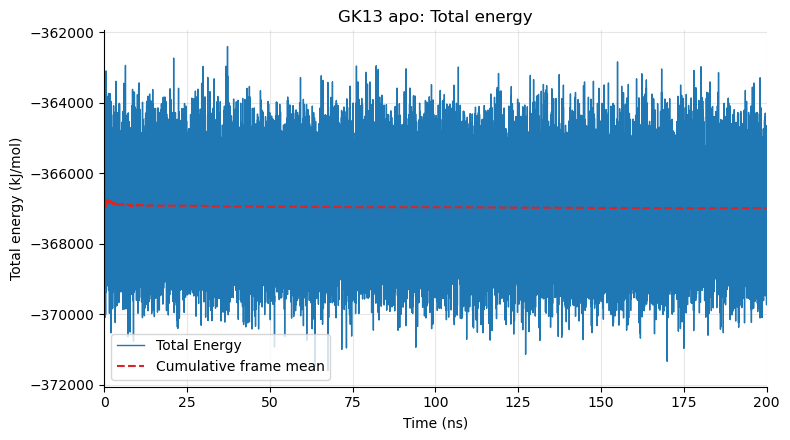

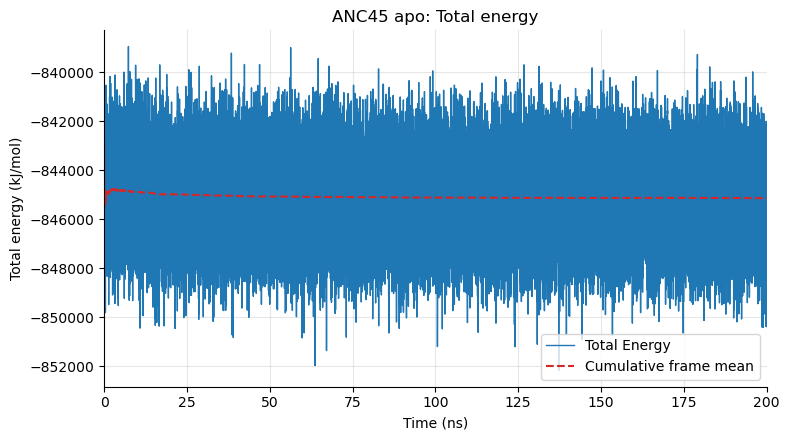

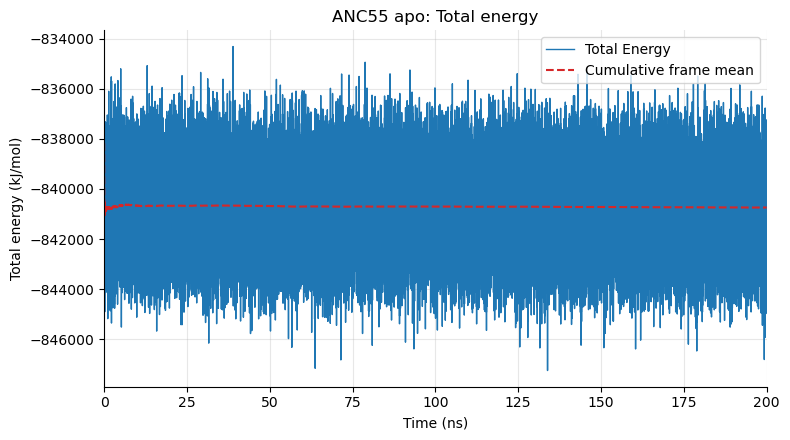

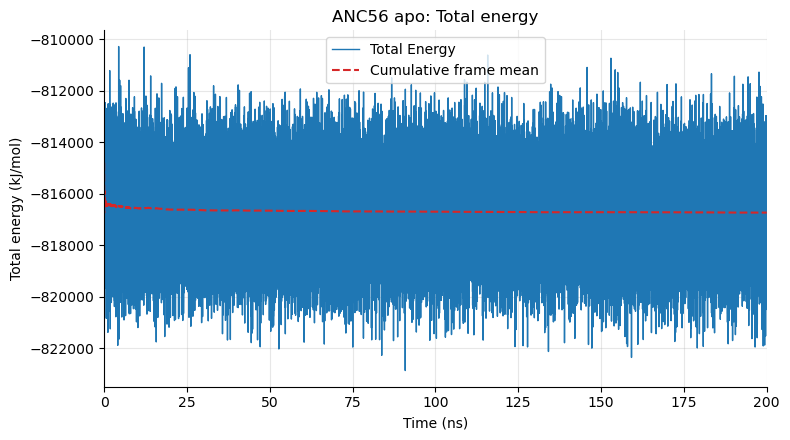

In [6]:
# Figure 1 — edit colours, labels, line widths and axes here, then rerun this cell.
for enzyme in PLOT_SYSTEMS:
    data, prefix = load_plot_data(enzyme, "total_energy", "total_energy_kj_mol")
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(data.time_ns, data.total_energy_kj_mol, color="tab:blue", linewidth=1.0,
            label="Total Energy")
    ax.plot(data.time_ns, data.total_energy_kj_mol.expanding().mean(),
            color="tab:red", linestyle="--", linewidth=1.5, label="Cumulative frame mean")
    ax.set(xlabel="Time (ns)", ylabel="Total energy (kJ/mol)",
           title=f"{enzyme} apo: Total energy", xlim=(START_NS, END_NS))
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(f"{prefix}_total_energy.png", dpi=PNG_DPI)
    display(fig)
    plt.close(fig)


### Figure 2 — apo protein backbone RMSD

GK13 apo: mean=2.1650 Å; SD=0.3360 Å; final 20% mean=2.4043 Å


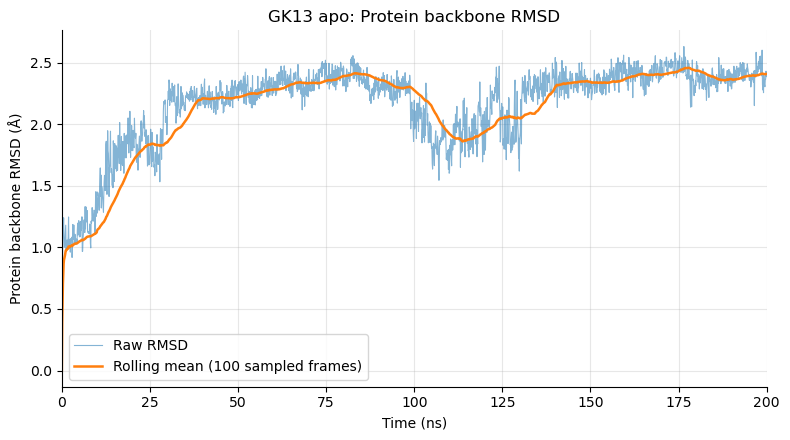

ANC45 apo: mean=2.0213 Å; SD=0.4995 Å; final 20% mean=2.3625 Å


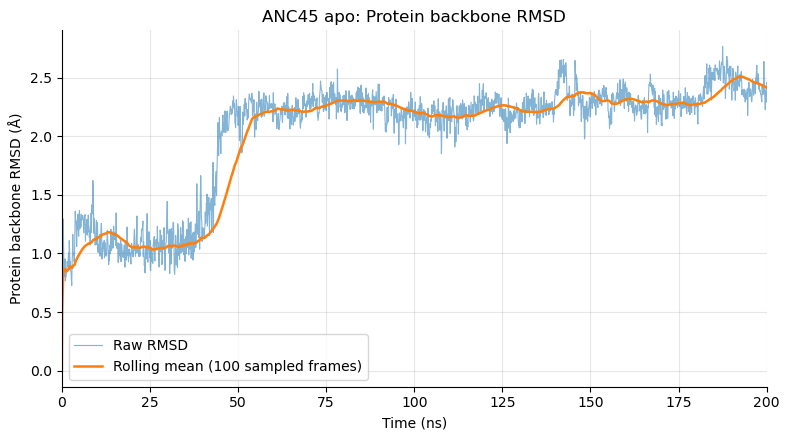

ANC55 apo: mean=1.4602 Å; SD=0.4665 Å; final 20% mean=2.1379 Å


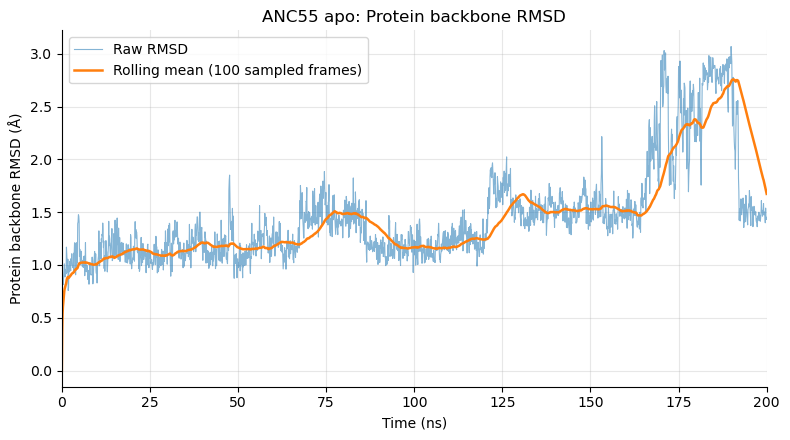

ANC56 apo: mean=1.3389 Å; SD=0.2100 Å; final 20% mean=1.6050 Å


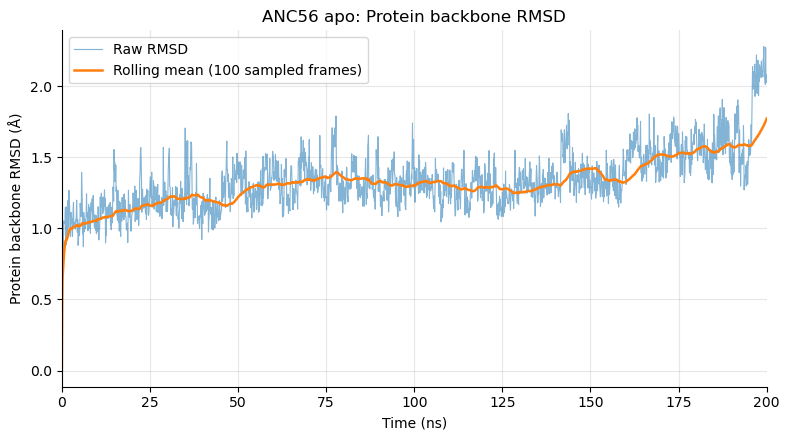

In [4]:
# Figure 2 — edit this cell and rerun it independently of the analysis.
for enzyme in PLOT_SYSTEMS:
    data, prefix = load_plot_data(enzyme, "protein_backbone_rmsd", "protein_backbone_rmsd_nm")
    values = data["protein_backbone_rmsd_nm"] * 10  # nm → Å for plotting
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(data.time_ns, values, color="tab:blue", linewidth=0.8, alpha=0.55,
            label="Raw RMSD")
    if PLOT_ROLLING_WINDOW is not None:
        mean = values.rolling(PLOT_ROLLING_WINDOW, min_periods=1).mean()
        ax.plot(data.time_ns, mean, color="tab:orange", linewidth=1.8,
                label=f"Rolling mean ({PLOT_ROLLING_WINDOW} sampled frames)")
    ax.set(xlabel="Time (ns)", ylabel="Protein backbone RMSD (Å)",
           title=f"{enzyme} apo: Protein backbone RMSD", xlim=(START_NS, END_NS))
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(f"{prefix}_protein_backbone_rmsd.png", dpi=PNG_DPI)
    final_count = max(1, int(np.ceil(0.20 * len(values))))
    print(f"{enzyme} apo: mean={values.mean():.4f} Å; SD={values.std():.4f} Å; "
          f"final 20% mean={values.iloc[-final_count:].mean():.4f} Å")
    display(fig)
    plt.close(fig)


### Comparison figures — GK13 and ANC45, 0–200 ns

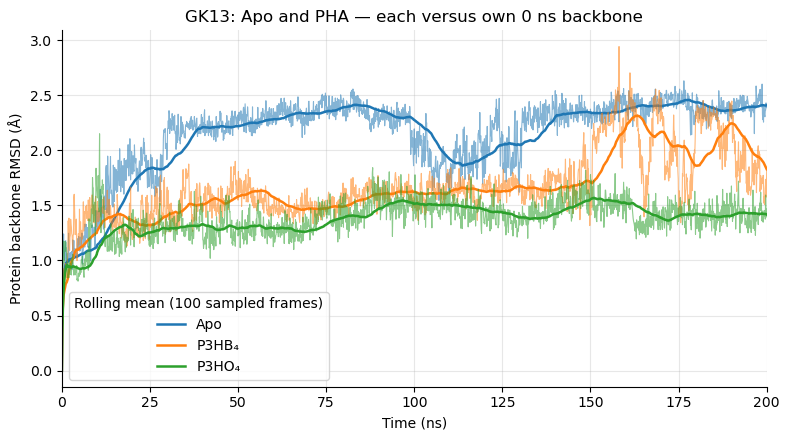

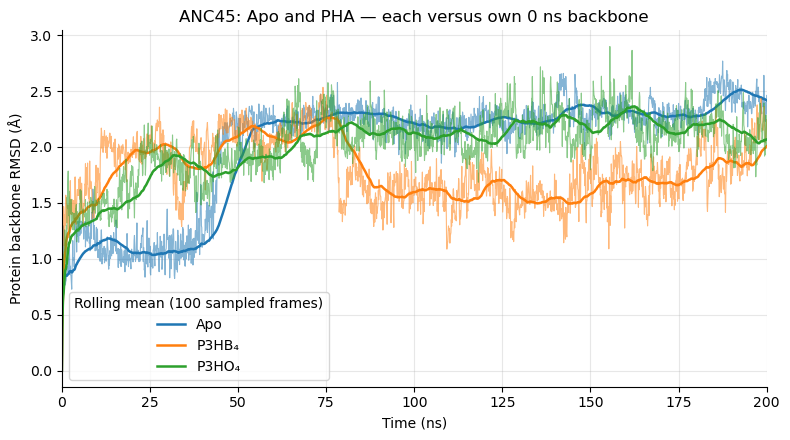

In [5]:
CONDITION_STYLES = {"apo": ("Apo", "tab:blue"), "P3HB4": ("P3HB₄", "tab:orange"),
                    "P3HO4": ("P3HO₄", "tab:green")}
for enzyme in COMPARISON_SYSTEMS:
    prefix = apo_prefix(enzyme)
    report = json.loads(Path(f"{prefix}_comparison_check.json").read_text())
    if report["status"] != "compatible_own_first_frame":
        print(f"No overlay for {enzyme}: {report.get('issue', 'compatibility not verified')}")
        continue
    data = pd.read_csv(f"{prefix}_rmsd_comparison.csv")
    if set(data.condition) != set(CONDITION_STYLES):
        raise ValueError("Expected apo, P3HB4 and P3HO4 comparison data.")
    spacing = []
    for condition in CONDITION_STYLES:
        curve = data.loc[data.condition == condition]
        steps = np.diff(curve.time_ns)
        if len(curve) < 2 or not np.isfinite(curve[["time_ns", "protein_backbone_rmsd_nm"]]).all().all() or np.any(steps <= 0):
            raise ValueError("Invalid comparison data.")
        if not curve.time_ns.between(START_NS, END_NS).all():
            raise ValueError("Comparison data outside 0–200 ns.")
        spacing.append(steps)
    if PLOT_ROLLING_WINDOW is not None and not all(np.allclose(s, spacing[0][0], atol=1e-8, rtol=0) for s in spacing):
        raise ValueError("Different sample spacing: set PLOT_ROLLING_WINDOW=None to compare raw curves.")
    fig, ax = plt.subplots(figsize=FIGSIZE)
    for condition, (label, colour) in CONDITION_STYLES.items():
        curve = data.loc[data.condition == condition]
        values = curve.protein_backbone_rmsd_nm * 10  # nm → Å for plotting
        ax.plot(curve.time_ns, values, color=colour, linewidth=0.8,
                alpha=0.55, label=label if PLOT_ROLLING_WINDOW is None else "_nolegend_")
        if PLOT_ROLLING_WINDOW is not None:
            mean = values.rolling(PLOT_ROLLING_WINDOW, min_periods=1).mean()
            ax.plot(curve.time_ns, mean, color=colour, linewidth=1.8, label=label)
    ax.set(xlabel="Time (ns)", ylabel="Protein backbone RMSD (Å)",
           title=f"{enzyme}: Apo and PHA — each versus own 0 ns backbone", xlim=(START_NS, END_NS))
    ax.grid(alpha=0.3)
    ax.legend(title=None if PLOT_ROLLING_WINDOW is None else f"Rolling mean ({PLOT_ROLLING_WINDOW} sampled frames)")
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(f"{prefix}_rmsd_comparison.png", dpi=PNG_DPI)
    display(fig)
    plt.close(fig)


## 6. Outputs and rerunning

Each `PHA_APO/<enzyme>_gromacs/analysis/` folder receives:
- `<enzyme>_apo_research_0_200ns_total_energy.png/.csv`
- `<enzyme>_apo_research_0_200ns_protein_backbone_rmsd.png/.csv`
- `<enzyme>_apo_research_0_200ns_energy.log` and `..._summary.json`

GK13 and ANC45 additionally receive `..._rmsd_comparison.png/.csv` and `..._comparison_check.json`. ANC55 and ANC56 have individual apo results only. PHA inputs/results are read-only. PNGs contain rolling means computed from the CSV values; CSVs retain unsmoothed RMSD values in nm (figures display Å), so you can change `PLOT_ROLLING_WINDOW` without recalculating RMSD. Energy CSVs include a cumulative sample-mean column.

Keep `RUN_ANALYSIS=False` for plot edits. After restarting the kernel, run **1. Paths**, **5. Plot settings**, and the desired figure cell. For fresh calculations, choose a new `OUTPUT_TAG` and enable `RUN_ANALYSIS`. `OVERWRITE=True` explicitly permits replacement of that tag's calculated files; `SAVE_FIGURES` separately controls PNG writes.

Whole-protein bond checks and matching atom counts do not alone prove XTC atom identity; these inputs use the matching production TPR and documented all-System preprocessing. Comparisons show relative backbone displacement, not binding affinity or a statistical test of stability. Total energies of different-sized solvent systems are not directly comparable; energy figures are per-system diagnostics.

Methods: [MDAnalysis RMSD](https://docs.mdanalysis.org/stable/documentation_pages/analysis/rms.html), [GROMACS energy](https://manual.gromacs.org/current/onlinehelp/gmx-energy.html).